# Breast Cancer Classification with a Neural Network

## Project Overview
This notebook trains a small feed-forward neural network (TensorFlow/Keras) to classify breast tumours as **malignant** or **benign** from 30 numeric measurements. It uses the Breast Cancer Wisconsin (Diagnostic) dataset that ships with scikit-learn.

This is a **tabular binary classification** project. No images are involved.

## Problem Statement
Given 30 numeric features computed from digitised images of fine-needle-aspirate (FNA) samples of breast masses, predict whether the tumour is malignant or benign.

## Objectives
- Load and inspect the scikit-learn Breast Cancer Wisconsin dataset and check its quality.
- Split the data with a reproducible, stratified train/test split.
- Standardise the features, fitting the scaler on the training data only.
- Build and train a simple neural network classifier.
- Evaluate it on the held-out test set with accuracy, precision, recall, F1-score, a confusion matrix and ROC-AUC.
- Demonstrate the inference workflow for a 30-feature sample using the same fitted scaler and model.

## Dataset
The data comes from `sklearn.datasets.load_breast_cancer`: 569 samples, 30 numeric features (mean, standard error and "worst" value of ten cell-nucleus measurements) and one binary target.

**Target mapping** (verified programmatically below):

| Value | Class |
|-------|-------|
| 0 | Malignant |
| 1 | Benign |

Note that the *malignant* class is encoded as `0`. Keep this in mind when reading precision, recall and ROC-AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from tensorflow import keras

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)

In [2]:
dataset = load_breast_cancer(as_frame=True)
df = dataset.frame

# Verify the target mapping from the dataset metadata: index in target_names == target value
CLASS_NAMES = [name.capitalize() for name in dataset.target_names]
assert CLASS_NAMES == ["Malignant", "Benign"]
assert set(df["target"].unique()) == {0, 1}

for value, name in enumerate(CLASS_NAMES):
    print(f"{value} = {name}")

0 = Malignant
1 = Benign


## Data Exploration

In [3]:
print(f"Samples: {df.shape[0]}, columns: {df.shape[1]} (30 features + 1 target)")
df.head()

Samples: 569, columns: 31 (30 features + 1 target)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
class_counts = df["target"].value_counts().sort_index()
class_distribution = pd.DataFrame(
    {"count": class_counts.values, "percent": (class_counts / len(df) * 100).round(1).values},
    index=pd.Index(CLASS_NAMES, name="class"),
)
class_distribution

,count,percent
class,,
Malignant,212,37.3
Benign,357,62.7


In [5]:
# Mean of the ten "mean ..." features per class
class_label = df["target"].map(dict(enumerate(CLASS_NAMES))).rename("class")
df.drop(columns="target").iloc[:, :10].groupby(class_label).mean().T.round(3)

class,Benign,Malignant
mean radius,12.147,17.463
mean texture,17.915,21.605
mean perimeter,78.075,115.365
mean area,462.790,978.376
mean smoothness,0.092,0.103
mean compactness,0.080,0.145
mean concavity,0.046,0.161
mean concave points,0.026,0.088
mean symmetry,0.174,0.193
mean fractal dimension,0.063,0.063


## Data Quality

In [6]:
features_only = df.drop(columns="target")

print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("All feature columns numeric:", all(pd.api.types.is_numeric_dtype(t) for t in features_only.dtypes))

Missing values: 0
Duplicate rows: 0
All feature columns numeric: True


## Feature/Target Separation

In [7]:
X = df.drop(columns="target")
y = df["target"]
FEATURE_NAMES = X.columns.to_list()

print(f"X: {X.shape}, y: {y.shape}")

X: (569, 30), y: (569,)


## Train/Test Split
80% of the data is used for training and 20% for testing. The split is **stratified** on the target so both sets keep the original class proportions, and it is seeded for reproducibility.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
pd.DataFrame(
    {
        "train": y_train.value_counts(normalize=True).sort_index().round(3).values,
        "test": y_test.value_counts(normalize=True).sort_index().round(3).values,
    },
    index=pd.Index(CLASS_NAMES, name="class proportion"),
)

Train: (455, 30), Test: (114, 30)


,train,test
class proportion,,
Malignant,0.374,0.368
Benign,0.626,0.632


## Feature Scaling
Features are on very different scales (for example `mean area` vs. `mean smoothness`). `StandardScaler` is **fitted on the training data only** and then applied to the test data, so no test-set information leaks into training.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train per-feature mean, max absolute value: {np.abs(X_train_scaled.mean(axis=0)).max():.2e}")
print(f"Train per-feature std, min / max: {X_train_scaled.std(axis=0).min():.3f} / {X_train_scaled.std(axis=0).max():.3f}")

Train per-feature mean, max absolute value: 8.74e-16
Train per-feature std, min / max: 1.000 / 1.000


## Neural Network Architecture
A deliberately small network for tabular data:

- `Input(shape=(30,))`: the 30 standardised features
- `Dense(20, activation="relu")`: one hidden layer
- `Dense(2, activation="softmax")`: probabilities for the two classes (0 = Malignant, 1 = Benign)

It is compiled with the Adam optimiser and sparse categorical cross-entropy, which matches integer class labels and a softmax output.

In [10]:
model = keras.Sequential(
    [
        keras.Input(shape=(30,)),
        keras.layers.Dense(20, activation="relu"),
        keras.layers.Dense(2, activation="softmax"),
    ],
    name="breast_cancer_classifier",
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "breast_cancer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662 (2.59 KB)

 Trainable params: 662 (2.59 KB)

 Non-trainable params: 0 (0.00 B)

## Training
10% of the training data is held out as a validation set to monitor generalisation during training. The test set is not used here.

In [11]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.1,
    epochs=10,
    verbose=2,
)

Epoch 1/10
13/13 - 4s - 292ms/step - accuracy: 0.4083 - loss: 0.8457 - val_accuracy: 0.5652 - val_loss: 0.7013
Epoch 2/10
13/13 - 0s - 21ms/step - accuracy: 0.6699 - loss: 0.5930 - val_accuracy: 0.6739 - val_loss: 0.5432
Epoch 3/10
13/13 - 0s - 35ms/step - accuracy: 0.8215 - loss: 0.4371 - val_accuracy: 0.8261 - val_loss: 0.4422
Epoch 4/10
13/13 - 0s - 31ms/step - accuracy: 0.8900 - loss: 0.3419 - val_accuracy: 0.8478 - val_loss: 0.3726
Epoch 5/10
13/13 - 1s - 55ms/step - accuracy: 0.9267 - loss: 0.2801 - val_accuracy: 0.9130 - val_loss: 0.3206
Epoch 6/10
13/13 - 0s - 28ms/step - accuracy: 0.9413 - loss: 0.2368 - val_accuracy: 0.9130 - val_loss: 0.2797
Epoch 7/10
13/13 - 1s - 56ms/step - accuracy: 0.9413 - loss: 0.2047 - val_accuracy: 0.9130 - val_loss: 0.2470
Epoch 8/10
13/13 - 0s - 32ms/step - accuracy: 0.9487 - loss: 0.1802 - val_accuracy: 0.9348 - val_loss: 0.2205
Epoch 9/10
13/13 - 0s - 24ms/step - accuracy: 0.9511 - loss: 0.1611 - val_accuracy: 0.9348 - val_loss: 0.1987
Epoch 10/

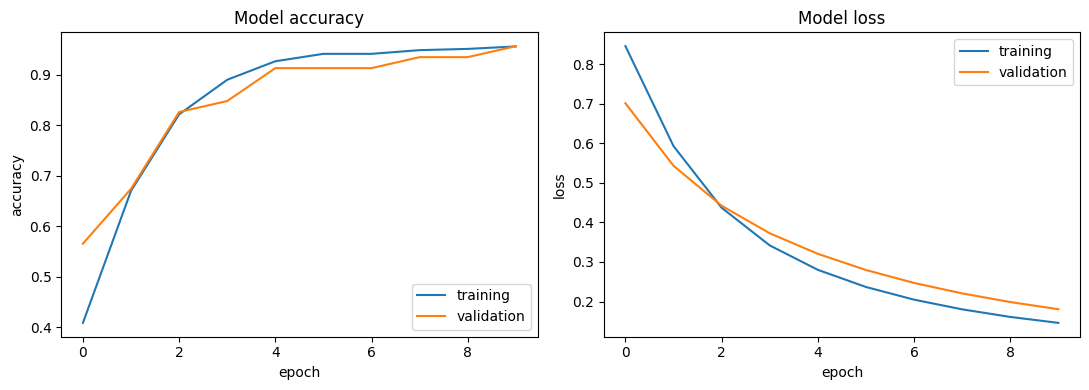

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["accuracy"], label="training")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Model accuracy")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy")
axes[0].legend(loc="lower right")

axes[1].plot(history.history["loss"], label="training")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Model loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Evaluation
The model is evaluated once on the held-out test set. Predicted classes are the argmax of the softmax probabilities. Precision, recall and F1-score are reported **per class**, since the two classes matter differently. ROC-AUC is computed from the predicted probability of class 1 (Benign).

In [13]:
y_proba = model.predict(X_test_scaled, verbose=0)
y_pred = y_proba.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba[:, 1])
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1])

print(f"Test accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC:  {roc_auc:.4f}")

pd.DataFrame(
    {"Precision": precision, "Recall": recall, "F1-score": f1, "Support": support},
    index=pd.Index(CLASS_NAMES, name="class"),
).round(4)

Test accuracy: 0.9474
Test ROC-AUC:  0.9821


,Precision,Recall,F1-score,Support
class,,,,
Malignant,0.9286,0.9286,0.9286,42
Benign,0.9583,0.9583,0.9583,72


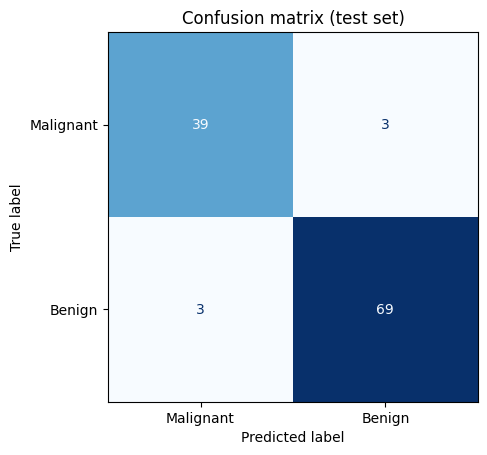

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix (test set)")
plt.show()

## Example Prediction
This section demonstrates the inference workflow for a single sample. The sample is a record taken from the dataset itself, so it is **not** independent validation and does not represent unseen or clinical data.

The sample is provided as a dictionary with all 30 named features, arranged in the training column order, standardised with the **same scaler fitted on the training data**, and passed to the trained model.


In [15]:
example_sample_features = {
    "mean radius": 11.76,
    "mean texture": 21.6,
    "mean perimeter": 74.72,
    "mean area": 427.9,
    "mean smoothness": 0.08637,
    "mean compactness": 0.04966,
    "mean concavity": 0.01657,
    "mean concave points": 0.01115,
    "mean symmetry": 0.1495,
    "mean fractal dimension": 0.05888,
    "radius error": 0.4062,
    "texture error": 1.21,
    "perimeter error": 2.635,
    "area error": 28.47,
    "smoothness error": 0.005857,
    "compactness error": 0.009758,
    "concavity error": 0.01168,
    "concave points error": 0.007445,
    "symmetry error": 0.02406,
    "fractal dimension error": 0.001769,
    "worst radius": 12.98,
    "worst texture": 25.72,
    "worst perimeter": 82.98,
    "worst area": 516.5,
    "worst smoothness": 0.1085,
    "worst compactness": 0.08615,
    "worst concavity": 0.05523,
    "worst concave points": 0.03715,
    "worst symmetry": 0.2433,
    "worst fractal dimension": 0.06563,
}

assert set(example_sample_features) == set(FEATURE_NAMES), "Input must contain exactly the 30 dataset features."

# A DataFrame with the training column names/order keeps the scaler's feature names consistent
example_sample = pd.DataFrame([example_sample_features], columns=FEATURE_NAMES)
example_sample_scaled = scaler.transform(example_sample)

probabilities = model.predict(example_sample_scaled, verbose=0)[0]
predicted_class = CLASS_NAMES[int(np.argmax(probabilities))]

print(f"Predicted class: {predicted_class}")
print(f"Class probabilities: Malignant = {probabilities[0]:.4f}, Benign = {probabilities[1]:.4f}")

Predicted class: Benign
Class probabilities: Malignant = 0.0422, Benign = 0.9578


## Conclusion
A small fully connected network (one hidden layer of 20 units, softmax output) was trained on standardised Breast Cancer Wisconsin features and evaluated on a stratified held-out test set. Its test-set performance is summarised by the accuracy, per-class precision/recall/F1, ROC-AUC and confusion matrix in the Evaluation section, which are computed from this notebook's own run. The example prediction demonstrates the inference workflow: a 30-feature record is scaled with the training scaler and classified by the trained model.

## Limitations
- The dataset is small (569 samples) and the test set contains only 114, so metrics carry considerable uncertainty. One split is used and there is no cross-validation.
- The architecture and hyperparameters (20 hidden units, 10 epochs) were not tuned, and no comparison with other models is made.
- Results can vary slightly across random seeds, library versions and hardware.
- The features are pre-extracted measurements from one dataset; performance on data from other sources, populations or imaging protocols is unknown.
- Errors of both kinds occur; see the confusion matrix. The model is not calibrated or clinically validated.

## Disclaimer
This project is for **educational purposes only**. It is not a medical device and its output must not be used for diagnosis, treatment or any clinical decision. Consult a qualified healthcare professional for medical concerns.